In [2]:
import torch

print("GPU Available:", torch.cuda.is_available())

GPU Available: True


In [3]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"asadejaz12","key":"5b03896240ef9b7cfc3f6cdff2d5a5a6"}'}

In [4]:
# Create the necessary folder and move kaggle.json there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [5]:
!kaggle datasets download -d bhavikjikadara/imdb-dataset-sentiment-analysis

Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/imdb-dataset-sentiment-analysis
License(s): apache-2.0
100% 25.7M/25.7M [00:01<00:00, 15.8MB/s]



In [6]:
!unzip imdb-dataset-sentiment-analysis.zip

Archive:  imdb-dataset-sentiment-analysis.zip
  inflating: IMDB_dataset.csv        


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('IMDB_dataset.csv')

In [9]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
df.duplicated().sum()

np.int64(418)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.isnull().sum()

,0
review,0
sentiment,0


In [13]:
df.shape

(49582, 2)

In [14]:
df['sentiment'].value_counts()

,count
sentiment,
positive,24884
negative,24698


In [15]:
df['sentiment']=df['sentiment'].map({'positive':1,'negative':0})

In [16]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [17]:
df['review']=df['review'].str.lower()

In [18]:
import re
df['review']=df['review'].apply(lambda x:re.sub(r'<.*?>','',x))

In [19]:
df['review']=df['review'].apply(lambda x:re.sub(r'[^\w\s]', '', x))

In [20]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming tech...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df['review'],df['sentiment'],test_size=0.2,random_state=42)

In [22]:
X_train= np.array(X_train)
X_test= np.array(X_test)
y_train= np.array(y_train)
y_test= np.array(y_test)

In [23]:
vocab_size = 10000
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)

In [24]:
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

In [25]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train = pad_sequences(X_train, maxlen=100,padding='post')
X_test = pad_sequences(X_test, maxlen=100,padding='post')


In [26]:
dict =tokenizer.word_index

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2



In [28]:
EMBED_DIM = 128
HIDDEN_DIM = 64

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, mask_zero=True),
    Bidirectional(LSTM(HIDDEN_DIM, return_sequences=False, dropout=0.3, recurrent_dropout=0.3)),
    Dropout(0.5),
    Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])


In [29]:
model.compile(
    optimizer='adam',
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
callback = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

In [31]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=128,
    epochs=10,
    callbacks=[callback]
)

Epoch 1/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 258s 792ms/step - accuracy: 0.7581 - loss: 0.5146 - val_accuracy: 0.8450 - val_loss: 0.3729
Epoch 2/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 242s 780ms/step - accuracy: 0.8781 - loss: 0.3174 - val_accuracy: 0.8607 - val_loss: 0.3353
Epoch 3/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 242s 782ms/step - accuracy: 0.8967 - loss: 0.2737 - val_accuracy: 0.8533 - val_loss: 0.3440
Epoch 4/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 261s 778ms/step - accuracy: 0.9145 - loss: 0.2331 - val_accuracy: 0.8489 - val_loss: 0.3519
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.


In [35]:
model.save('Sentiment-Analysis.keras')

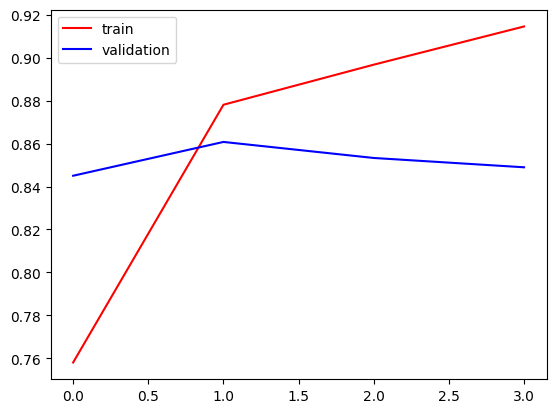

In [33]:
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()


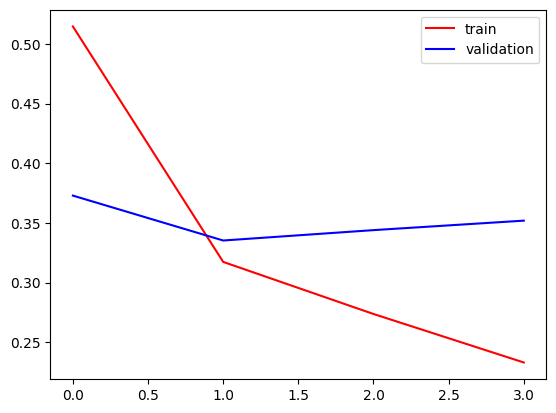

In [34]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()
